In [0]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import h5py
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
# 1.Read the h5 dataset.
d_path="/content/drive/My Drive/GLLAB/SVHN_single_grey1.h5"


In [4]:

# Open the file as readonly
h5f = h5py.File(d_path, 'r')

# Load the training, test and validation set
X_train = h5f['X_train'][:]
y_train = h5f['y_train'][:]
X_test = h5f['X_test'][:]
y_test = h5f['y_test'][:]
X_val = h5f['X_val'][:]
y_val = h5f['y_val'][:]

# Close this file
h5f.close()

print('Training set', X_train.shape, y_train.shape)
print('Validation set', X_val.shape, y_val.shape)
print('Test set', X_test.shape, y_test.shape)

Training set (42000, 32, 32) (42000,)
Validation set (60000, 32, 32) (60000,)
Test set (18000, 32, 32) (18000,)


Label: 0


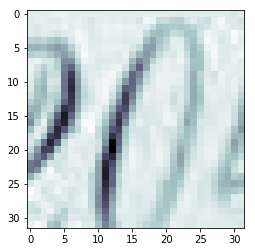

In [5]:
# Show one of the images from the training dataset
img_index=7
plt.imshow(X_train[img_index],cmap=plt.cm.bone)
print ("Label:" ,y_train[img_index])

In [0]:
%matplotlib inline
plt.rcParams['figure.figsize'] = (16.0, 4.0)

In [0]:
def plot_images(img, labels, nrows, ncols):
    """ Plot nrows x ncols images
    """
    fig, axes = plt.subplots(nrows, ncols)
    for i, ax in enumerate(axes.flat): 
        if img[i].shape == (32,32):
            ax.imshow(img[i])
        else:
            ax.imshow(img[i,:,:,0])
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(labels[i])

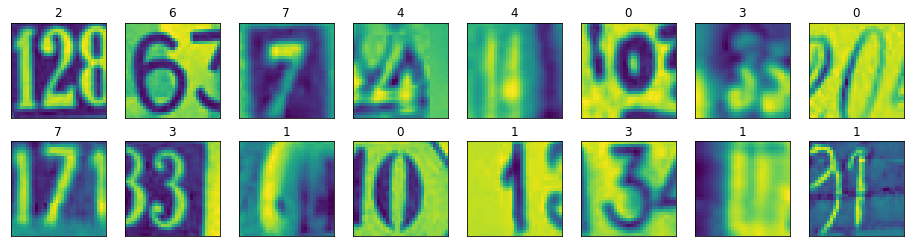

In [8]:
# Plot some training set images
plot_images(X_train, y_train, 2, 8)

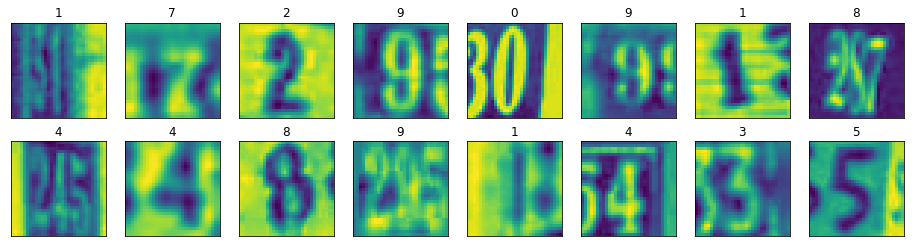

In [96]:
# Plot some test set images
plot_images(X_test, y_test, 2, 8)

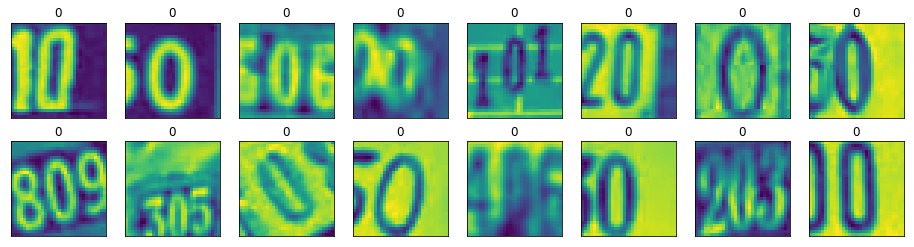

In [97]:
# Plot some test set images
plot_images(X_val, y_val, 2, 8)

In [13]:
#To check unique labels
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


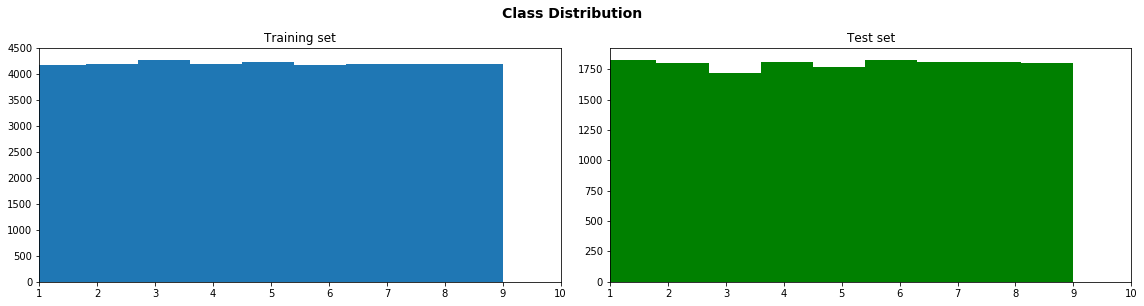

In [14]:
#Plotting Distribution of Data ( Train and Test)
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

fig.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.05)

ax1.hist(y_train, bins=10)
ax1.set_title("Training set")
ax1.set_xlim(1, 10)

ax2.hist(y_test, color='g', bins=10)
ax2.set_title("Test set")

fig.tight_layout()

In [0]:
#All data distributed equally.

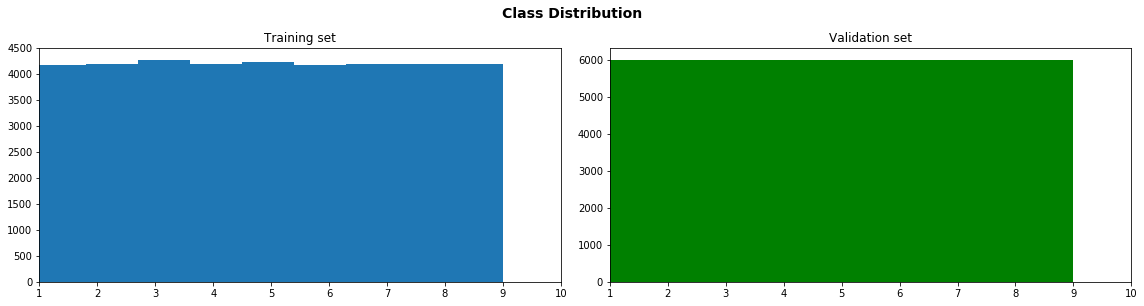

In [15]:
#Plotting Distribution of Data ( Train and Test)
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True)

fig.suptitle('Class Distribution', fontsize=14, fontweight='bold', y=1.05)

ax1.hist(y_train, bins=10)
ax1.set_title("Training set")
ax1.set_xlim(1, 10)

ax2.hist(y_val, color='g', bins=10)
ax2.set_title("Validation set")

fig.tight_layout()

In [0]:
#Normalization refers to normalizing the data dimensions so that they are of approximately the same scale. Divide each dimension by its standard deviation, once it has been zero-centered.

In [0]:
# Calculate the mean on the training data
train_mean = np.mean(X_train, axis=0)

# Calculate the std on the training data
train_std = np.std(X_train, axis=0)

# Subtract it equally from all splits
X_train_norm = (X_train - train_mean) / train_std
X_test_norm = (X_test - train_mean)  / train_std
X_val_norm = (X_val - train_mean) / train_std


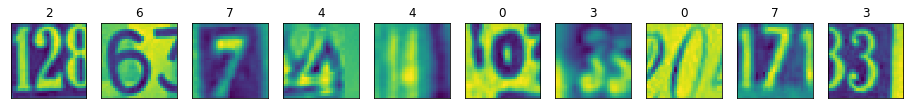

In [99]:
# Plotting After Normalization
plot_images(X_train_norm, y_train, 1, 10)

In [0]:
## k-Nearest Neighbor (kNN) classifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [19]:
X_train.shape

(42000, 32, 32)

In [0]:
#It is taking too much time to train the full set. Hence I am going to Split 50% for only kNN model
from sklearn.model_selection import train_test_split

In [0]:
# split into 50% for train and 50% for test for validation
X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(X_val_norm, y_val, test_size=0.70, random_state=7)

In [0]:
# split into 50% for train and 50% for test
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_train_norm, y_train, test_size=0.50, random_state=7)

In [13]:
X_train_knn.shape

(21000, 32, 32)

In [0]:
nsamples, nx, ny = X_train_knn.shape
X_train_dataset = X_train_knn.reshape((nsamples,nx*ny))

nsamples, nx, ny = X_test_knn.shape
X_test_dataset = X_test_knn.reshape((nsamples,nx*ny))

In [16]:
 # train the k-Nearest Neighbor classifier with the current value of `3`
  model = KNeighborsClassifier(n_neighbors=3)
  model.fit(X_train_dataset, y_train_knn)
  # evaluate the model and update the accuracies list
  score = model.score(X_test_dataset, y_test_knn )
  print( score * 100)

41.84761904761905


In [17]:
 # train the k-Nearest Neighbor classifier with the current value of `10`
  model = KNeighborsClassifier(n_neighbors=10)
  model.fit(X_train_dataset, y_train_knn)
  # evaluate the model and update the accuracies list
  score = model.score(X_test_dataset, y_test_knn )
  print( score * 100)

46.36190476190476


In [15]:
 # train the k-Nearest Neighbor classifier with the current value of `15`
  model = KNeighborsClassifier(n_neighbors=15)
  model.fit(X_train_dataset, y_train_knn)
  # evaluate the model and update the accuracies list
  score = model.score(X_test_dataset, y_test_knn )
  print( score * 100)

48.16666666666667


In [16]:
X_train_val.shape

(18000, 32, 32)

In [0]:
nsamples, nx, ny = X_train_val.shape
X_val_dataset = X_train_val.reshape((nsamples,nx*ny))

In [0]:
predictions = model.predict(X_val_dataset)

In [22]:
predictions[1]

5

In [0]:
#Print the classification metric report (2.5 points)

In [33]:
print("Classification Metric Report")
print(classification_report(y_train_val, predictions))

Classification Metric Report
              precision    recall  f1-score   support

           0       0.45      0.68      0.54      1838
           1       0.45      0.73      0.55      1804
           2       0.62      0.55      0.58      1804
           3       0.49      0.44      0.46      1785
           4       0.62      0.63      0.63      1832
           5       0.49      0.42      0.45      1784
           6       0.50      0.39      0.44      1806
           7       0.68      0.61      0.65      1731
           8       0.47      0.37      0.42      1804
           9       0.56      0.38      0.46      1812

    accuracy                           0.52     18000
   macro avg       0.53      0.52      0.52     18000
weighted avg       0.53      0.52      0.52     18000



In [0]:
##Conculsion : kNN is not really useful. It is really pain to generate the results even though results will not be good.

In [0]:
#Implement and apply a deep neural network classifier including (feedforward neural network, RELU activations) (5 points)

## Preparing for DNN kenral.


In [11]:
from sklearn.preprocessing import OneHotEncoder
 
# Fit the OneHotEncoder
enc = OneHotEncoder().fit(y_train.reshape(-1, 1))

# Transform the label values to a one-hot-encoding scheme
y_train = enc.transform(y_train.reshape(-1, 1)).toarray()
y_test = enc.transform(y_test.reshape(-1, 1)).toarray()
y_val = enc.transform(y_val.reshape(-1, 1)).toarray()

print("Training set", y_train.shape)
print("Validation set", y_val.shape)
print("Test set", y_test.shape)

Training set (42000, 10)
Validation set (60000, 10)
Test set (18000, 10)


/usr/local/lib/python3.6/dist-packages/sklearn/preprocessing/_encoders.py:415: FutureWarning: The handling of integer data will change in version 0.22. Currently, the categories are determined based on the range [0, max(values)], while in the future they will be determined based on the unique values.
If you want the future behaviour and silence this warning, you can specify "categories='auto'".
In case you used a LabelEncoder before this OneHotEncoder to convert the categories to integers, then you can now use the OneHotEncoder directly.
  warnings.warn(msg, FutureWarning)


In [0]:
##convert each 32 x 32 image of the train and test set into a matrix of size 32 x 32 x 1 which is fed into the network.
X_train = X_train_norm.reshape(-1, 32,32, 1)
X_test = X_test_norm.reshape(-1, 32,32, 1)
X_Val = X_val_norm.reshape(-1, 32,32, 1)

In [0]:
#The data right now is in an int8 format, so before you feed it into the network you need to convert its type to float32
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_val = X_val.astype('float32')

In [0]:
### Import the necessary layers from keras to build the model

In [0]:
import keras
from keras.models import Sequential,Input,Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers.advanced_activations import LeakyReLU
from keras.optimizers import SGD

In [18]:
#Initialize model
model = tf.keras.models.Sequential()

#Add Layers
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
checkpt= tf.keras.callbacks.EarlyStopping(monitor='acc',  patience=5, verbose=0, mode='auto', baseline=None, restore_best_weights=True)

In [22]:
# Fit the model
model.fit(X_train, y_train, epochs=5, batch_size=5,callbacks = [checkpt],validation_data=(X_test,y_test))

Train on 42000 samples, validate on 18000 samples
Epoch 1/5
42000/42000 [==============================] - 444s 11ms/sample - loss: 0.0596 - acc: 0.9842 - val_loss: 1.3027 - val_acc: 0.8727
Epoch 2/5
42000/42000 [==============================] - 410s 10ms/sample - loss: 0.0508 - acc: 0.9866 - val_loss: 1.3168 - val_acc: 0.8676
Epoch 3/5
42000/42000 [==============================] - 408s 10ms/sample - loss: 0.0530 - acc: 0.9870 - val_loss: 1.5390 - val_acc: 0.8690
Epoch 4/5
42000/42000 [==============================] - 410s 10ms/sample - loss: 0.0509 - acc: 0.9884 - val_loss: 1.5359 - val_acc: 0.8757
Epoch 5/5
42000/42000 [==============================] - 414s 10ms/sample - loss: 0.0521 - acc: 0.9884 - val_loss: 1.6444 - val_acc: 0.8717


In [0]:
test_eval_a = model.evaluate(X_test, y_test, verbose=0)

In [25]:
print('Test loss: ', test_eval_a[0])
print('Test accuracy:  % 5.2f' % (test_eval_a[1]*100) ,'%' )

Test loss:  1.6443798960795004
Test accuracy:   87.17 %


In [31]:
X_Val.shape

(60000, 32, 32, 1)

In [0]:
prediction = model.predict(X_Val)


In [49]:
np.argmax(prediction[4000])

1

Label: 2


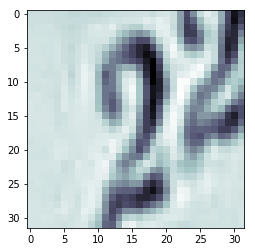

In [68]:
# Show one of the images from the training dataset
img_index=45000
plt.imshow(X_Val[img_index].reshape(32,32),cmap=plt.cm.bone)
print ("Label:" ,np.argmax(prediction[img_index]))

In [0]:
#Understand and be able to implement (vectorized) backpropagation (cost stochastic gradient descent, cross entropy loss, cost functions) (2.5 points)

from keras import optimizers
#Initialize model, reshape & normalize data
model_sgd = tf.keras.models.Sequential()

#Add Layers
model_sgd.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_sgd.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_sgd.add(tf.keras.layers.Flatten())
model_sgd.add(tf.keras.layers.Dense(128, activation='relu'))
model_sgd.add(tf.keras.layers.Dense(10, activation='softmax'))


In [0]:
sgd = tf.keras.optimizers.SGD(lr=0.01, decay=1e-6, momentum=0.9, nesterov=True)
model_sgd.compile( loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [67]:
# Fit the model
model_sgd.fit(X_train, y_train, epochs=5, batch_size=5,callbacks = [checkpt],validation_data=(X_test,y_test))

Train on 42000 samples, validate on 18000 samples
Epoch 1/5
42000/42000 [==============================] - 400s 10ms/sample - loss: 1.3773 - acc: 0.5609 - val_loss: 1.0375 - val_acc: 0.6894
Epoch 2/5
42000/42000 [==============================] - 403s 10ms/sample - loss: 1.1066 - acc: 0.6650 - val_loss: 1.1189 - val_acc: 0.6635
Epoch 3/5
42000/42000 [==============================] - 403s 10ms/sample - loss: 1.0638 - acc: 0.6868 - val_loss: 1.0602 - val_acc: 0.6733
Epoch 4/5
42000/42000 [==============================] - 401s 10ms/sample - loss: 1.0136 - acc: 0.7052 - val_loss: 1.2763 - val_acc: 0.6361
Epoch 5/5
42000/42000 [==============================] - 402s 10ms/sample - loss: 1.0065 - acc: 0.7083 - val_loss: 1.1429 - val_acc: 0.6826


In [0]:
test_eval_sgd = model_sgd.evaluate(X_test, y_test, verbose=0)

In [70]:
print('Test loss: ', test_eval_sgd[0])
print('Test accuracy:  % 5.2f' % (test_eval_sgd[1]*100) ,'%' )

Test loss:  1.1428851380348206
Test accuracy:   68.26 %


In [0]:
# SGD accuracy is very less compare to Adam

In [0]:
prediction_sgd = model_sgd.predict(X_Val)

Label: 2


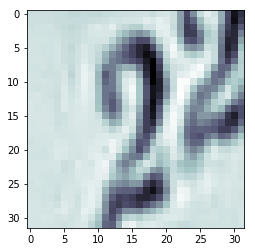

In [73]:
# Show one of the images from the training dataset
img_index=45000
plt.imshow(X_Val[img_index].reshape(32,32),cmap=plt.cm.bone)
print ("Label:" ,np.argmax(prediction_sgd[img_index]))

In [0]:
#Implement batch normalization for training the neural network (2.5 points)

In [0]:
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import BatchNormalization

train_datagen = ImageDataGenerator(
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)
train_datagen.fit(X_train)
train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size = 32
)

steps = int(X_train.shape[0] / 64)

In [0]:

#Initialize model, reshape & normalize data
model_bo = tf.keras.models.Sequential()

#Add Layers
model_bo.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_bo.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model_bo.add(tf.keras.layers.BatchNormalization())
model_bo.add(tf.keras.layers.Flatten())
model_bo.add(tf.keras.layers.Dense(128, activation='relu'))
model_bo.add(tf.keras.layers.Dense(10, activation='softmax'))
model_bo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [0]:
checkpt_bo= tf.keras.callbacks.EarlyStopping(monitor='acc',  patience=5, verbose=0, mode='auto', baseline=None, restore_best_weights=True)

In [80]:
bo_history = model_bo.fit_generator(train_generator,  steps_per_epoch = steps,epochs = 10,validation_data = (X_test, y_test),callbacks = [checkpt])


Epoch 1/10
656/656 [==============================] - 87s 133ms/step - loss: 0.3920 - acc: 0.8770 - val_loss: 0.4533 - val_acc: 0.8696
Epoch 2/10
656/656 [==============================] - 87s 133ms/step - loss: 0.4076 - acc: 0.8754 - val_loss: 0.4638 - val_acc: 0.8677
Epoch 3/10
656/656 [==============================] - 87s 133ms/step - loss: 0.3698 - acc: 0.8877 - val_loss: 0.4546 - val_acc: 0.8647
Epoch 4/10
656/656 [==============================] - 87s 132ms/step - loss: 0.3832 - acc: 0.8844 - val_loss: 0.4460 - val_acc: 0.8711
Epoch 5/10
656/656 [==============================] - 87s 132ms/step - loss: 0.3527 - acc: 0.8922 - val_loss: 0.4319 - val_acc: 0.8720
Epoch 6/10
656/656 [==============================] - 86s 131ms/step - loss: 0.3444 - acc: 0.8914 - val_loss: 0.4447 - val_acc: 0.8689
Epoch 7/10
656/656 [==============================] - 86s 131ms/step - loss: 0.3279 - acc: 0.9009 - val_loss: 0.4477 - val_acc: 0.8667
Epoch 8/10
656/656 [==============================] - 8

In [0]:
test_eval_ob = model_bo.evaluate(X_test, y_test, verbose=0)

In [82]:
print('Test loss: ', test_eval_ob[0])
print('Test accuracy:  % 5.2f' % (test_eval_ob[1]*100) ,'%' )

Test loss:  0.432295969956451
Test accuracy:   88.06 %


In [0]:
prediction_bo = model_bo.predict(X_Val)

Label: 5


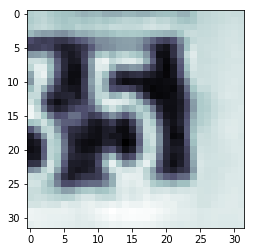

In [87]:
# Show one of the images from the training dataset
img_index=50000
plt.imshow(X_Val[img_index].reshape(32,32),cmap=plt.cm.bone)
print ("Label:" ,np.argmax(prediction_bo[img_index]))

In [0]:
# Conclusion : Adam with Batch optimisation accuracyis good compare to other models. 